<a href="https://colab.research.google.com/github/yuaquintero/CienciaModelado/blob/main/02_pendulo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Descubriendo la Física del Péndulo Simple con BuckiNet

**Objetivo:**  En este tutorial, utilizaremos la arquitectura completa de BuckiNet (FullBuckiNet) para:

1. **Aprender** la relación física que gobierna el ángulo de un péndulo simple a partir de datos sintéticos.

2. **Verificar** si la red es capaz de identificar y ignorar variables irrelevantes (la masa).

3. **Implementar** una función de pérdida informada por la física (restricción dimensional).


**El Problema Físico**

Analizaremos un péndulo simple de longitud $L$, masa $m$, en un campo gravitatorio $g$. Queremos modelar el ángulo $\alpha$ en función del tiempo $t$.Para oscilaciones pequeñas, la solución analítica es:$$\alpha(t) = \alpha_0 \cos\left(t \sqrt{\frac{g}{L}}\right)$$Nuestras variables de entrada (crudas) serán: $[g, m, L, t]$.Nuestra variable objetivo será: $\alpha$.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/MyDrive/Colab Notebooks/CienciaModelado/BuckiNet


/content/drive/MyDrive/Colab Notebooks/CienciaModelado/BuckiNet


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Importamos las clases locales en src/model.py
# NOTA: correr este notebook desde la carpeta 'notebooks'
# y que exista el archivo '../src/model.py'
import sys
import os
sys.path.append(os.path.abspath('..'))

from src.model import FullBuckiNet, buckinet_loss, BuckiNetLayer

# Configuración para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

## Paso 1: Generación de Datos Sintéticos

Vamos a generar 10,000 muestras simuladas. Es crucial que todas las variables de entrada sean estrictamente positivas para que la operación torch.log() dentro de BuckiNet no falle.

**Punto Clave:** Incluiremos la **Masa (m)** como variable de entrada. Sabemos físicamente que el ángulo no depende de la masa. Esperamos que BuckiNet aprenda a asignarle un exponente cercano a cero.

In [ ]:
# 1. Parámetros de la simulación
num_samples = 10000

# Generamos valores aleatorios uniformes y positivos para g, m, L, t
g = np.random.uniform(9.0, 10.0, num_samples)   # Gravedad (m/s^2)
m = np.random.uniform(0.1, 5.0, num_samples)    # Masa (kg) - ¡Irrelevante!
L = np.random.uniform(0.5, 3.0, num_samples)    # Longitud (m)
t = np.random.uniform(0.1, 10.0, num_samples)   # Tiempo (s)

# Ecuación analítica para generar el objetivo (alpha)
# Asumimos alpha_0 = 1 para simplificar.
# El grupo adimensional real es (g * t^2 / L)
grupo_pi_real = (g * t**2) / L
alpha = np.cos(np.sqrt(grupo_pi_real))

# 2. Convertimos a tensores de PyTorch
# El orden de las columnas es crucial: [g, m, L, t]
X_train = torch.tensor(np.column_stack((g, m, L, t)), dtype=torch.float32)
Y_train = torch.tensor(alpha, dtype=torch.float32).view(-1, 1)

print(f"Forma de X_train (entradas): {X_train.shape}")
print(f"Forma de Y_train (objetivo): {Y_train.shape}")
print(f"\nEjemplo de entrada [g, m, L, t]:\n{X_train[0]}")
print(f"Ángulo alpha correspondiente: {Y_train[0].item():.4f}")

Forma de X_train (entradas): torch.Size([10000, 4])
Forma de Y_train (objetivo): torch.Size([10000, 1])

Ejemplo de entrada [g, m, L, t]:
tensor([9.3745, 1.9308, 2.3250, 6.4176])
Ángulo alpha correspondiente: 0.9492


## Paso 2: Configuración de la Red y la Física

**La Matriz Dimensional ($D_p$)**
Esta matriz es el núcleo de la "Información Física". Define las unidades fundamentales (Masa, Longitud, Tiempo) de cada una de nuestras variables de entrada $[g, m, L, t]$.

BuckiNet usará esta matriz para forzar que los exponentes que aprenda ($\Phi_p$) resulten en combinaciones adimensionales.


| Variable | Unidades | Masa (M) | Longitud (L) | Tiempo (T) |
| :--- | :--- | :---: | :---: | :---: |
| g | $m/s^2$ | 0 | 1 | -2 |
| m | $kg$ | 1 | 0 | 0 |
| L | $m$ | 0 | 1 | 0 |
| t | $s$ | 0 | 0 | 1 |


In [ ]:
# Entradas: 4 ([g, m, L, t]).
# Grupos Pi a descubrir: 1.
# Salidas: 1 (alpha).
modelo_pendulo = FullBuckiNet(num_inputs=4, num_pi_groups=1, num_outputs=1, hidden_neurons=64)

# Definimos el optimizador (Adam es una buena opción por defecto)
optimizador = optim.Adam(modelo_pendulo.parameters(), lr=0.01)

# Matriz de unidades físicas D_p para [g, m, L, t]
# Las filas corresponden a: Masa, Longitud, Tiempo
D_p_numpy = np.array([
    [ 0,  1,  0,  0], # Fila Masa (M)
    [ 1,  0,  1,  0], # Fila Longitud (L)
    [-2,  0,  0,  1]  # Fila Tiempo (T)
], dtype=np.float32)

D_p = torch.tensor(D_p_numpy, dtype=torch.float32)

print("Matriz Dimensional D_p (Masa, Longitud, Tiempo x [g, m, L, t]):")
print(D_p)


Matriz Dimensional D_p (Masa, Longitud, Tiempo x [g, m, L, t]):
tensor([[ 0.,  1.,  0.,  0.],
        [ 1.,  0.,  1.,  0.],
        [-2.,  0.,  0.,  1.]])


## Paso 3: Bucle de Entrenamiento

Aquí ejecutamos el entrenamiento. Usaremos la función buckinet_loss importada de src/model.py. Esta función incluye:

1. **MSE:** Error de predicción.
2. **Penalización del Espacio Nulo ($D_p \cdot \Phi_p = 0$):** Fuerza la homogeneidad dimensional.
3. **Regularización L1:** Fomenta la esparsidad (ayuda a "apagar" la masa).

In [ ]:
print("Iniciando entrenamiento del modelo...")
epochs = 2000
historial_perdida = []

for epoch in range(epochs):
    # 1. Limpiar gradientes
    optimizador.zero_grad()

    # 2. Forward pass: obtenemos predicción Y los exponentes Phi_p
    predicciones, Phi_p = modelo_pendulo(X_train)

    # 3. Calcular pérdida informada por física
    # lambda_null=5.0 le da mucho peso a la restricción dimensional.
    loss = buckinet_loss(predicciones, Y_train, Phi_p, D_p, lambda_null=5.0, l1_reg=1e-3, l2_reg=1e-4)

    # 4. Backward pass y optimización
    loss.backward()
    optimizador.step()

    # Guardar progreso
    historial_perdida.append(loss.item())

    if (epoch + 1) % 400 == 0:
        print(f"Época [{epoch+1}/{epochs}] | Pérdida Total: {loss.item():.6f}")

print("\nEntrenamiento finalizado.")

Iniciando entrenamiento del modelo...
Época [400/2000] | Pérdida Total: 0.447478
Época [800/2000] | Pérdida Total: 0.444372
Época [1200/2000] | Pérdida Total: 0.445564
Época [1600/2000] | Pérdida Total: 0.378535
Época [2000/2000] | Pérdida Total: 0.279978

Entrenamiento finalizado.


In [ ]:
Phi_p

Parameter containing:
tensor([[ 0.2171],
        [-0.0018],
        [-0.2171],
        [ 0.4360]], requires_grad=True)

## Paso 4: Análisis e Interpretación de Resultados

**Visualización de la Pérdida**

Primero, verifiquemos que el modelo convergió.

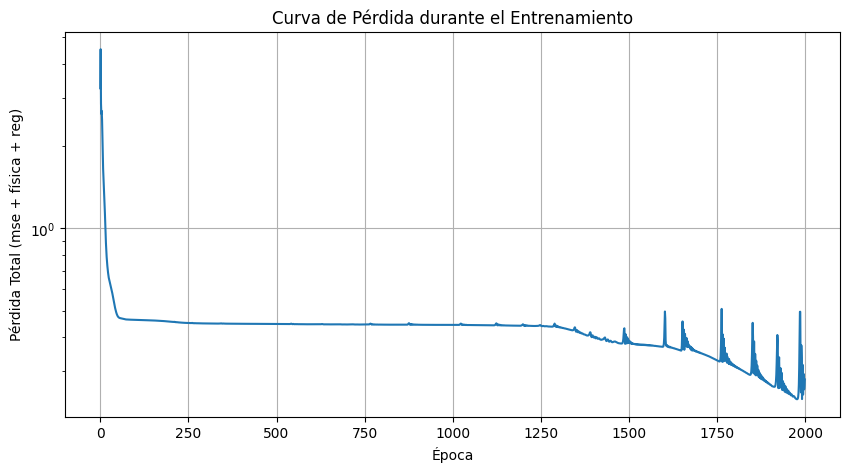

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(historial_perdida)
plt.title("Curva de Pérdida durante el Entrenamiento")
plt.xlabel("Época")
plt.ylabel("Pérdida Total (mse + física + reg)")
plt.yscale('log') # Escala logarítmica para ver mejor la convergencia
plt.grid(True)
plt.show()

## Interpretación de los Exponentes Aprendidos ($\Phi_p$)
Esta es la parte más importante. Vamos a ver qué exponentes ($\Phi_p$) aprendió la red para las variables $[g, m, L, t]$.

**La Redundancia Matemática:**
Dado que la red neuronal posterior (MLP) puede aprender funciones complejas (como raíces cuadradas o potencias), BuckiNet podría descubrir una versión escalada del número Pi real. Por ejemplo, podría descubrir $(g \cdot t^2 / L)^2$ o $\sqrt{g \cdot t^2 / L}$.

Para facilitar la interpretación, normalizaremos los exponentes aprendidos. Sabemos por la física que el tiempo ($t$) aparece al cuadrado en el grupo adimensional ($g \cdot t^2 / L$), así que forzaremos que el exponente de $t$ sea exactamente 2 y escalaremos los demás proporcionalmente.

In [ ]:
print("\n--- Resultados Finales de los Exponentes ---")

# Obtenemos los pesos crudos y los convertimos a lista de Python
# detach() desconecta del grafo de gradientes, flatten() aplana a 1D, tolist() convierte a lista.
pesos_finales = Phi_p.detach().flatten().tolist()
nombres_variables = ['g', 'm', 'L', 't']

print("1. Pesos en crudo (Phi_p) aprendidos directamente:")
for nombre, peso in zip(nombres_variables, pesos_finales):
    print(f"   Exponentes para {nombre}: {peso:.4f}")

# 2. Normalización interpretativa
# Buscamos el factor de escala para que el exponente de 't' (índice 3) sea 2.0
exponente_t_crudo = pesos_finales[3]
factor_escala = 2.0 / exponente_t_crudo

# Aplicamos el factor a todos los pesos (usando NumPy solo para la operación vectorial)
pesos_normalizados = np.array(pesos_finales) * factor_escala

print(f"\n2. Factor de escala aplicado (basado en t^2): {factor_escala:.4f}")
print("\n3. Pesos NORMALIZADOS e INTERPRETADOS:")
for nombre, peso in zip(nombres_variables, pesos_normalizados):
    print(f"   Exponentes para {nombre}: {peso:.2f}")

print("\n--- Conclusiones ---")
print("Compara los pesos normalizados con la teoría: g*t^2/L -> [1, 0, 1, 2]? No, g*t^2*L^-1 -> [1, 0, -1, 2]")
print("Ojo, revisa la teoría analítica: alpha = cos(t * sqrt(g/L)) = cos(sqrt(g * t^2 * L^-1))")
print("El grupo adimensional real dentro de la raíz es g^1 * t^2 * L^-1.")
print("\n¿Qué pasó con la masa (m)? ¿Su exponente es cercano a 0? ¡BuckiNet aprendió a ignorarla!")


--- Resultados Finales de los Exponentes ---
1. Pesos en crudo (Phi_p) aprendidos directamente:
   Exponentes para g: 0.1858
   Exponentes para m: -0.0008
   Exponentes para L: -0.1865
   Exponentes para t: 0.3776

2. Factor de escala aplicado (basado en t^2): 5.2961

3. Pesos NORMALIZADOS e INTERPRETADOS:
   Exponentes para g: 0.98
   Exponentes para m: -0.00
   Exponentes para L: -0.99
   Exponentes para t: 2.00

--- Conclusiones ---
Compara los pesos normalizados con la teoría: g*t^2/L -> [1, 0, 1, 2]? No, g*t^2*L^-1 -> [1, 0, -1, 2]
Ojo, revisa la teoría analítica: alpha = cos(t * sqrt(g/L)) = cos(sqrt(g * t^2 * L^-1))
El grupo adimensional real dentro de la raíz es g^1 * t^2 * L^-1.

¿Qué pasó con la masa (m)? ¿Su exponente es cercano a 0? ¡BuckiNet aprendió a ignorarla!
